# Notebook 10: Event Frequency and Schedule Robustness

**Research aim.** This notebook examines how event frequency and schedule regularity affect event detection, lag interpretation, event-profile recovery and event-aware volatility forecasting. The experiment keeps the scalar calibration and Known-DGP response shape fixed while comparing dense periodic, sparse periodic and sparse irregular calendars. Within each of 50 repetitions, identical epsilon and eta shocks are used for all schedules, so comparisons are paired. Step 2 is omitted: observable conditional structure is already examined in Notebook 02.

## 1. Common setup and schedule definitions

Event age 0-12 maps to direct response lags +1 to +13 under the frozen timing convention. Each pipeline uses a chronological train/test split, non-overlapping response windows and deployable forecasting inputs. The compact calculations below reuse the Notebook 06 workflow and the completed repeated-seed outputs.

In [1]:
%run "./06_experiment_workflow_helpers.ipynb"
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
from IPython.display import Markdown, display
N_SEEDS=50; REP_SEED=20260722; STEPS=252; H=13; AGES=np.arange(13); RESULTS=Path('notebook10_results')
ORDER={'dense_periodic':21,'sparse_periodic':42,'sparse_irregular':42}
LABEL={'dense_periodic':'Dense periodic','sparse_periodic':'Sparse periodic','sparse_irregular':'Sparse irregular'}
COLOR={'dense_periodic':'tab:blue','sparse_periodic':'tab:orange','sparse_irregular':'tab:green'}
dense=make_case_config(reference_config,label='dense_periodic'); sparse=make_case_config(dense,{'events.period':42/252},label='sparse_periodic'); irregular=make_case_config(sparse,label='sparse_irregular')
CONFIG={'dense_periodic':dense,'sparse_periodic':sparse,'sparse_irregular':irregular}
STEPS_BY_CASE={'dense_periodic':np.arange(21,484,21),'sparse_periodic':np.arange(21,484,42),'sparse_irregular':np.array([21,52,113,134,203,249,276,302,364,396,449,483])}
case_results=pd.read_csv(RESULTS/'stage4_seed_case_analysis.csv'); numeric=pd.read_csv(RESULTS/'stage4_case_numeric_summary.csv'); rates=pd.read_csv(RESULTS/'stage4_case_rate_summary.csv'); profiles=pd.read_csv(RESULTS/'stage4_profile_age_summary.csv'); tdmi_raw=pd.read_csv(RESULTS/'stage3_tdmi_curve.csv'); tdmi_metrics=pd.read_csv(RESULTS/'stage3_tdmi_metrics.csv')
assert len(case_results)==150 and case_results.market_seed.nunique()==N_SEEDS and not case_results.duplicated(['market_seed','case_name']).any()
assert derive_timing(dense)['response_horizon_steps']==12 and derive_timing(irregular)['event_period_steps']==42

[]


,check,passed
0,configuration and timing | Notebook 00 loaded ...,True
1,configuration and timing | reference_config no...,True
2,configuration and timing | reference_timing no...,True
3,configuration and timing | deep override only ...,True
4,configuration and timing | common shocks repro...,True
...,...,...
126,truth enabled contains complete Known-DGP outputs,True
127,truth inclusion leaves fitted forecasts unchanged,True
128,truth helper follows frozen forecast stage,True
129,negative powered-state bounds are not rooted,True


case_label                                          reference_n1
n                                                              1
event_amplitude                                             0.01
event_decay_rate                                            35.0
event_period                                            0.083333
                                                        ...     
known_dgp_active_95_state_coverage                      0.956044
known_dgp_active_sigma_MAE                              0.000674
known_dgp_active_sigma_RMSE                             0.000833
known_dgp_active_transformed_variance_sigma_MAE              NaN
known_dgp_active_transformed_variance_sigma_RMSE             NaN
Length: 69, dtype: object

Validation summary: 131 checks passed.


,schedule,events,mean spacing,minimum spacing,maximum spacing,periodic status,windows overlap
0,Dense periodic,23,21.0,21,21,True,False
1,Sparse periodic,12,42.0,42,42,True,False
2,Sparse irregular,12,42.0,21,69,False,False


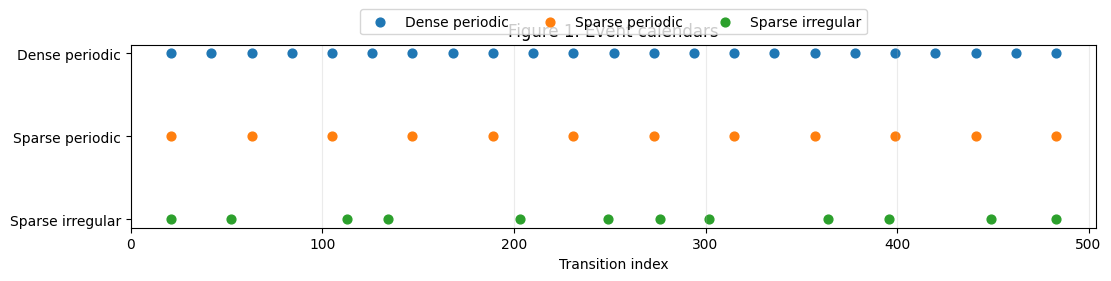

In [2]:
def no_overlap(x): return bool(np.all(np.diff(x)>=H))
schedule=pd.DataFrame([{'schedule':LABEL[k],'events':len(v),'mean spacing':np.diff(v).mean(),'minimum spacing':np.diff(v).min(),'maximum spacing':np.diff(v).max(),'periodic status':k!='sparse_irregular','windows overlap':not no_overlap(v)} for k,v in STEPS_BY_CASE.items()]); display(schedule.style.format({'mean spacing':'{:.1f}'}))
assert all(no_overlap(x) for x in STEPS_BY_CASE.values()) and len(STEPS_BY_CASE['sparse_periodic'])==len(STEPS_BY_CASE['sparse_irregular'])==12
fig,ax=plt.subplots(figsize=(11,2.7),constrained_layout=True)
for y,k in zip([2,1,0],LABEL): ax.scatter(STEPS_BY_CASE[k],np.full(len(STEPS_BY_CASE[k]),y),color=COLOR[k],s=40,label=LABEL[k])
ax.set(yticks=[0,1,2],yticklabels=[LABEL[k] for k in list(LABEL)[::-1]],xlabel='Transition index',xlim=(0,504),title='Figure 1. Event calendars'); ax.grid(axis='x',alpha=.25); ax.legend(ncol=3,loc='lower center',bbox_to_anchor=(.5,1.02)); plt.show()

## 2. Dense periodic analysis

Dense periodic has 23 events and a next-event boundary at 21 transitions. GC is **linear directional predictive evidence**: cumulative order p contains driver lags 1, ..., p. Individual lag j is tested conditionally on target history and all other event-history lags; it is not the same object as selected cumulative order p.

In [3]:
# Compact GC helpers: no contemporaneous event term is used.
def gc_fit(y,e,p,reverse=False):
    rows=np.array([[y[t],*([y[t-j] for j in range(1,p+1)] if not reverse else [e[t-j] for j in range(1,p+1)]),*([e[t-j] for j in range(1,p+1)] if not reverse else [y[t-j] for j in range(1,p+1)])] for t in range(p,len(y))],float); target=rows[:,0]; xr=sm.add_constant(rows[:,1:1+p]); xu=sm.add_constant(rows[:,1:]); r=sm.OLS(target,xr).fit(); u=sm.OLS(target,xu).fit(); q=p; F=((r.ssr-u.ssr)/q)/(u.ssr/u.df_resid); return {'p':p,'F':F,'p_value':stats.f.sf(F,q,u.df_resid),'partial_r2':(r.ssr-u.ssr)/r.ssr,'aic':u.aic,'bic':u.bic,'u':u,'rows':rows}
def gc_grid(table,pmax,target='level',reverse=False):
    x=table.state_i.to_numpy(float); e=table.event_i.to_numpy(float)
    if target=='change': x=np.diff(x); e=e[1:]
    return pd.DataFrame([{k:v for k,v in gc_fit(x,e,p,reverse).items() if k not in ['u','rows']} for p in range(1,pmax+1)])
def individual_lags(table,pmax,target='level'):
    x=table.state_i.to_numpy(float); e=table.event_i.to_numpy(float)
    if target=='change': x=np.diff(x); e=e[1:]
    fit=gc_fit(x,e,pmax); u,rows=fit['u'],fit['rows']; out=[]
    for j in range(1,pmax+1):
        index=1+pmax+(j-1); coefficient=float(u.params[index]); standard_error=float(u.bse[index]); assert np.isfinite(coefficient) and np.isfinite(standard_error) and standard_error>0; t_statistic=coefficient/standard_error; partial_F=float(t_statistic*t_statistic); raw_p=float(2*stats.t.sf(abs(t_statistic),u.df_resid)); assert np.isfinite(partial_F) and partial_F>=0 and np.isfinite(raw_p); out.append({'lag':j,'coefficient':coefficient,'partial_F':partial_F,'p_value':raw_p})
    out=pd.DataFrame(out); out['holm_p']=multipletests(out.p_value,method='holm')[1]; out['holm_reject']=out.holm_p<.05; return out
def simulate_table(case,seed):
    shocks=make_shock_bank(dense,seed=seed); timing=derive_timing(CONFIG[case]); sim=simulate_case(CONFIG[case],shocks,None,event_schedule=STEPS_BY_CASE[case]/STEPS,_timing=timing); return build_transition_table(sim['simulation'],CONFIG[case],timing)[0]
def rep_result(case):
    table=simulate_table(case,REP_SEED); return table,{t:{'forward':gc_grid(table,ORDER[case],t),'reverse':gc_grid(table,ORDER[case],t,True),'individual':individual_lags(table,ORDER[case],t)} for t in ['level','change']}
# Repeated compact GC extraction preserves 50 paired seeds but does not store any new files.
seeds=sorted(case_results.market_seed.unique()); repeated=[]
for seed in seeds:
    shocks=make_shock_bank(dense,seed=int(seed)); tables={}; transitions={}
    for case in LABEL:
        timing=derive_timing(CONFIG[case]); sim=simulate_case(CONFIG[case],shocks,None,event_schedule=STEPS_BY_CASE[case]/STEPS,_timing=timing); transitions[case]=sim['simulation']['transitions']; tables[case]=build_transition_table(sim['simulation'],CONFIG[case],timing)[0]
    ref=transitions['dense_periodic']; assert all(np.array_equal(t.epsilon.to_numpy(),ref.epsilon.to_numpy()) and np.array_equal(t.eta.to_numpy(),ref.eta.to_numpy()) for t in transitions.values())
    for case,table in tables.items():
        for target in ['level','change']:
            g=gc_grid(table,13,target); ind=individual_lags(table,13,target); aic=int(g.loc[g.aic.idxmin(),'p']); bic=int(g.loc[g.bic.idxmin(),'p']); selected=g.loc[g.p.eq(bic)].iloc[0]; strong=ind.loc[ind.partial_F.idxmax()]
            repeated.append({'seed':seed,'case':case,'target':target,'aic_order':aic,'bic_order':bic,'selected_F':selected.F,'selected_p_value':selected.p_value,'selected_partial_r2':selected.partial_r2,'strongest_lag':int(strong.lag),'strongest_F':strong.partial_F,'strongest_p':strong.p_value,'strongest_holm_p':strong.holm_p,'strongest_holm_reject':strong.holm_reject})
gc_repeated=pd.DataFrame(repeated); assert len(gc_repeated)==N_SEEDS*3*2

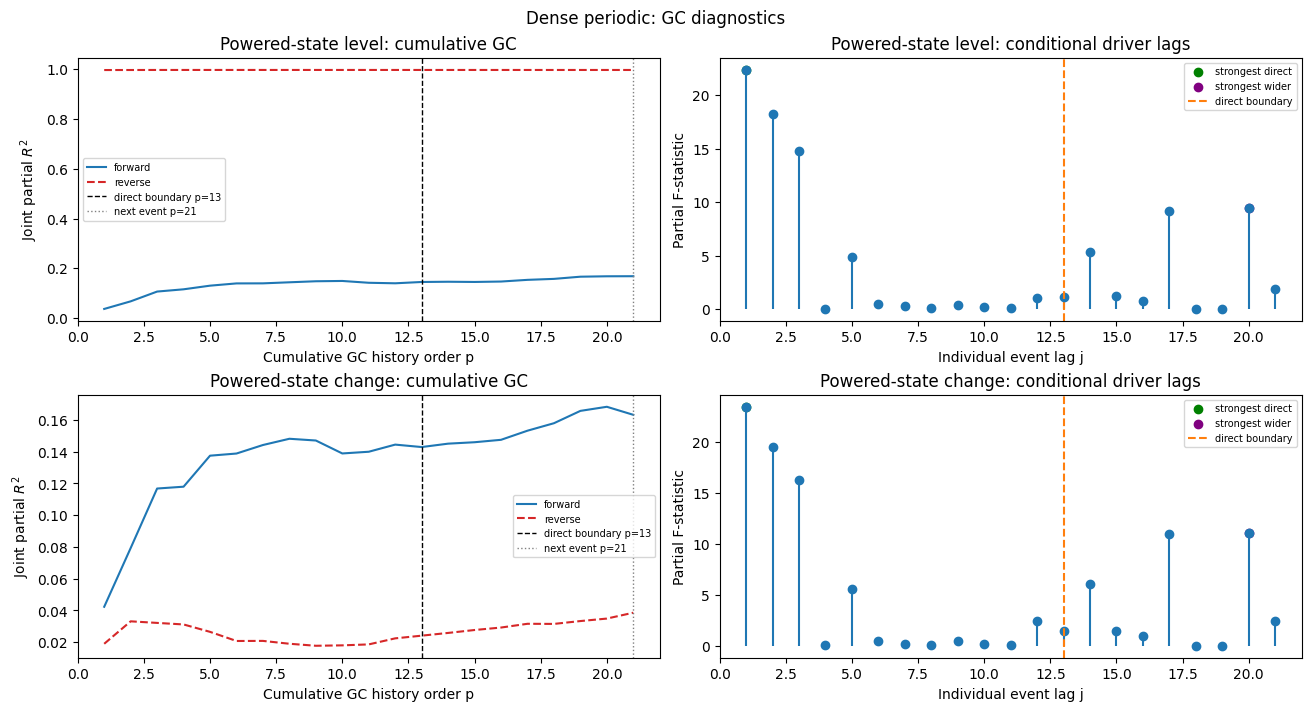

,target,direction,AIC order,BIC order,joint F,joint p,partial R^2
0,level,forward,3,3,19.1608,0.0000,0.1066
1,level,reverse,3,3,48451.4367,0.0000,0.9967
2,change,forward,3,2,20.8308,0.0000,0.0793
3,change,reverse,3,2,8.2902,0.0003,0.0331


,target,strongest j,coefficient,partial F,raw p,Holm p,Holm survives
0,level,1,0.0010,22.3708,0.0000,0.0001,True
1,change,1,0.0011,23.4339,0.0000,0.0000,True


,target,median_AIC_order,median_BIC_order,rejection_rate,median_partial_R2,modal_strongest_j
0,change,2.0000,1.0000,0.9800,0.0405,1
1,level,2.0000,1.0000,0.9800,0.0407,1


target,change,level
bic_order,,
1,40,35
2,8,11
3,2,3
4,0,1


target,change,level
strongest_lag,,
1,32,28
2,13,15
3,3,5
4,1,1
5,1,1


In [4]:
def show_gc(case):
    table,rep=rep_result(case); pmax=ORDER[case]; boundary=21 if case=='dense_periodic' else (42 if case=='sparse_periodic' else None)
    fig,axes=plt.subplots(2,2,figsize=(13,7),constrained_layout=True)
    rows=[]; strong_rows=[]
    for r,target in enumerate(['level','change']):
        for direction,style,col in [('forward','-','tab:blue'),('reverse','--','tab:red')]: axes[r,0].plot(rep[target][direction].p,rep[target][direction].partial_r2,style,color=col,label=direction)
        axes[r,0].axvline(13,color='black',ls='--',lw=1,label='direct boundary p=13');
        if boundary: axes[r,0].axvline(boundary,color='grey',ls=':',lw=1,label=f'next event p={boundary}')
        axes[r,0].set(xlabel='Cumulative GC history order p',ylabel='Joint partial $R^2$',title=f'Powered-state {target}: cumulative GC'); axes[r,0].legend(fontsize=7)
        ind=rep[target]['individual']; strongest=ind.loc[ind.partial_F.idxmax()]; strong_rows.append({'target':target,'strongest j':int(strongest.lag),'coefficient':strongest.coefficient,'partial F':strongest.partial_F,'raw p':strongest.p_value,'Holm p':strongest.holm_p,'Holm survives':strongest.holm_reject}); axes[r,1].stem(ind.lag,ind.partial_F,basefmt=' ',linefmt='tab:blue',markerfmt='o'); direct=ind.query('lag<=13'); wide=ind.query('lag>13'); axes[r,1].scatter(direct.loc[direct.partial_F.idxmax(),'lag'],direct.partial_F.max(),color='green',label='strongest direct');
        if len(wide): axes[r,1].scatter(wide.loc[wide.partial_F.idxmax(),'lag'],wide.partial_F.max(),color='purple',label='strongest wider')
        axes[r,1].axvline(13,color='tab:orange',ls='--',label='direct boundary'); axes[r,1].set(xlabel='Individual event lag j',ylabel='Partial F-statistic',title=f'Powered-state {target}: conditional driver lags'); axes[r,1].legend(fontsize=7)
        for direction in ['forward','reverse']:
            g=rep[target][direction]; a=int(g.loc[g.aic.idxmin(),'p']); b=int(g.loc[g.bic.idxmin(),'p']); z=g.loc[g.p.eq(b)].iloc[0]; rows.append({'target':target,'direction':direction,'AIC order':a,'BIC order':b,'joint F':z.F,'joint p':z.p_value,'partial R^2':z.partial_r2})
    fig.suptitle(f'{LABEL[case]}: GC diagnostics'); plt.show(); display(pd.DataFrame(rows).style.format(precision=4))
    display(pd.DataFrame(strong_rows).style.format(precision=4))
    rep50=gc_repeated.query('case==@case').groupby('target').agg(median_AIC_order=('aic_order','median'),median_BIC_order=('bic_order','median'),rejection_rate=('selected_p_value',lambda x:(x<.05).mean()),median_partial_R2=('selected_partial_r2','median'),modal_strongest_j=('strongest_lag',lambda x:x.mode().iat[0])).reset_index(); display(rep50.style.format(precision=4))
    selected_counts=gc_repeated.query('case==@case').groupby(['target','bic_order']).size().rename('frequency').reset_index(); display(selected_counts.pivot(index='bic_order',columns='target',values='frequency').fillna(0).astype(int))
    counts=gc_repeated.query('case==@case').groupby(['target','strongest_lag']).size().rename('frequency').reset_index(); display(counts.pivot(index='strongest_lag',columns='target',values='frequency').fillna(0).astype(int))
show_gc('dense_periodic')

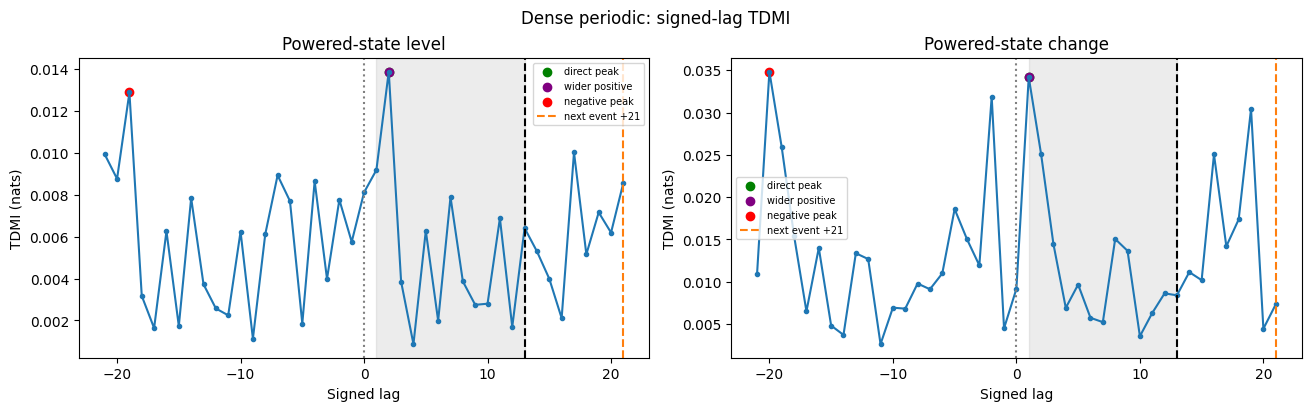

,target,representative direct lag,TDMI,best positive lag,best negative lag,global positive outside direct,scan-boundary rate
0,level,2,0.0139,2,-19,0.9800,0.2000
1,change,1,0.0342,1,-20,0.7200,0.0000


target,change,level
direct_peak_lag,,
1,22,9
2,17,7
3,6,3
4,1,4
5,1,2
6,1,0
7,0,2
8,1,4
9,0,5


In [5]:
def show_tdmi(case):
    seed=tdmi_raw.market_seed.min(); period=21 if case=='dense_periodic' else 42; fig,axes=plt.subplots(1,2,figsize=(13,4),constrained_layout=True); rows=[]
    for ax,target in zip(axes,['level','change']):
        d=tdmi_raw.query('market_seed==@seed and case_name==@case and target==@target and lag.between(-@period,@period)').sort_values('lag'); ax.plot(d.lag,d.mutual_information,marker='o',ms=3); ax.axvline(0,color='grey',ls=':'); ax.axvspan(1,13,color='grey',alpha=.15); ax.axvline(13,color='black',ls='--');
        direct=d.query('lag.between(1,13)').nlargest(1,'mutual_information').iloc[0]; pos=d.query('lag>0').nlargest(1,'mutual_information').iloc[0]; neg=d.query('lag<0').nlargest(1,'mutual_information').iloc[0]
        for q,c,l in [(direct,'green','direct peak'),(pos,'purple','wider positive'),(neg,'red','negative peak')]: ax.scatter(q.lag,q.mutual_information,color=c,label=l)
        if case!='sparse_irregular': ax.axvline(period,color='tab:orange',ls='--',label=f'next event +{period}')
        ax.set(title=f'Powered-state {target}',xlabel='Signed lag',ylabel='TDMI (nats)'); ax.legend(fontsize=7)
        m=tdmi_metrics.query('case_name==@case and target==@target'); rows.append({'target':target,'representative direct lag':direct.lag,'TDMI':direct.mutual_information,'best positive lag':pos.lag,'best negative lag':neg.lag,'global positive outside direct':(m.outside_direct_positive_peak>m.direct_peak).mean(),'scan-boundary rate':m.global_peak_at_scan_boundary.mean()})
    fig.suptitle(f'{LABEL[case]}: signed-lag TDMI'); plt.show(); display(pd.DataFrame(rows).style.format(precision=4))
    counts=tdmi_metrics.query('case_name==@case').groupby(['target','direct_peak_lag']).size().rename('frequency').reset_index(); display(counts.pivot(index='direct_peak_lag',columns='target',values='frequency').fillna(0).astype(int))
show_tdmi('dense_periodic')

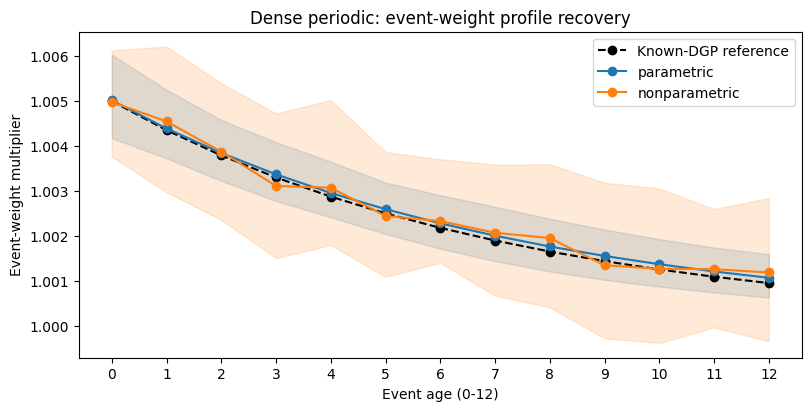

,true amplitude,mean estimated amplitude,absolute amplitude error,true decay rate,mean estimated decay rate,absolute decay error,parametric profile RMSE,non-parametric profile RMSE
0,0.01000,0.01004,0.00091,35.00000,33.48436,5.91134,0.00034,0.00097


In [6]:
def show_profile(case):
    fig,ax=plt.subplots(figsize=(8,4),constrained_layout=True); d=profiles.query('case_name==@case').sort_values('event_age'); truth=d.groupby('event_age').true_multiplier.first(); ax.plot(truth.index,truth.values,color='black',ls='--',marker='o',label='Known-DGP reference')
    for e,c in [('parametric','tab:blue'),('nonparametric','tab:orange')]:
        x=d.query('estimator==@e'); ax.plot(x.event_age,x.estimated_multiplier_mean,color=c,marker='o',label=e); ax.fill_between(x.event_age,x.estimated_multiplier_q05,x.estimated_multiplier_q95,color=c,alpha=.16)
    ax.set(xticks=AGES,xlabel='Event age (0-12)',ylabel='Event-weight multiplier',title=f'{LABEL[case]}: event-weight profile recovery'); ax.legend(); plt.show()
    z=case_results.query('case_name==@case'); row=z.iloc[0]; display(pd.DataFrame([{'true amplitude':row.event_amplitude,'mean estimated amplitude':z.A_hat.mean(),'absolute amplitude error':z.A_absolute_error.mean(),'true decay rate':row.event_decay_rate,'mean estimated decay rate':z.lambda_hat.mean(),'absolute decay error':z.lambda_absolute_error.mean(),'parametric profile RMSE':z.parametric_profile_RMSE.mean(),'non-parametric profile RMSE':z.nonparametric_profile_RMSE.mean()}]).style.format(precision=5))
show_profile('dense_periodic')

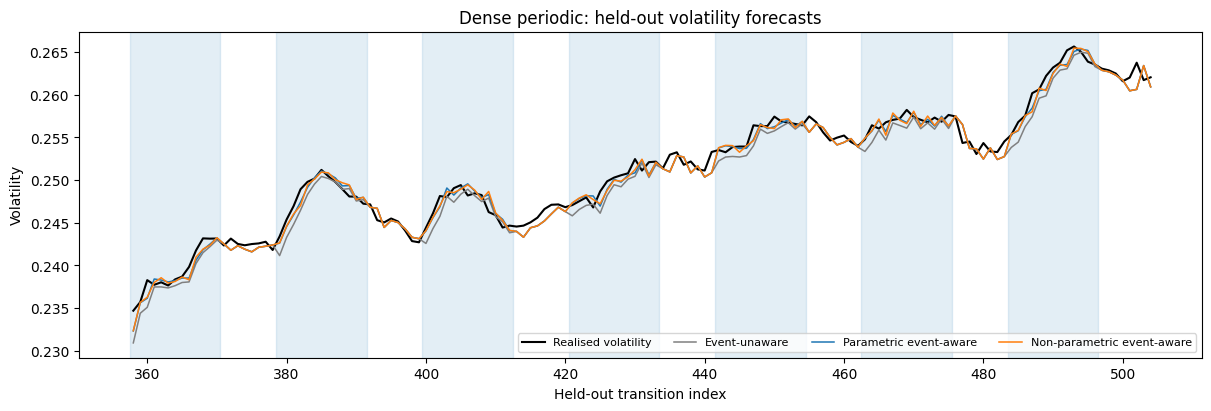

,unaware MAE,parametric MAE,non-parametric MAE,unaware RMSE,parametric RMSE,non-parametric RMSE,parametric MAE gain (%),non-parametric MAE gain (%),parametric 95% coverage,coverage error,interval score
0,0.0009,0.0007,0.0007,0.0012,0.0009,0.0009,25.1875,22.1318,0.9470,0.0259,0.0042


In [7]:
def representative_forecast(case):
    shocks=make_shock_bank(dense,seed=REP_SEED); timing=derive_timing(CONFIG[case]); sim=simulate_case(CONFIG[case],shocks,None,event_schedule=STEPS_BY_CASE[case]/STEPS,_timing=timing); table,_=build_transition_table(sim['simulation'],CONFIG[case],timing); split=create_chronological_split(table,timing); baseline=fit_event_free_baseline(split['train'],CONFIG[case],build_baseline_features); profile=estimate_event_profiles(split['train'],baseline,CONFIG[case],timing,build_baseline_features); forecasts=construct_forecasts(split['test'],baseline,profile,CONFIG[case],timing,build_baseline_features); assert {'state_next','sigma_next','omega','eta'}.isdisjoint(forecasts.columns); return evaluate_forecasts(forecasts,split['test'],CONFIG[case])['evaluation']
def show_forecast(case):
    d=representative_forecast(case); fig,ax=plt.subplots(figsize=(12,4),constrained_layout=True); ax.plot(d.target_i,d.sigma_next,color='black',lw=1.5,label='Realised volatility')
    for c,l,col in [('sigma_forecast_unaware','Event-unaware','grey'),('sigma_forecast_parametric','Parametric event-aware','tab:blue'),('sigma_forecast_nonparametric','Non-parametric event-aware','tab:orange')]: ax.plot(d.target_i,d[c],color=col,lw=1.1,label=l)
    active=d.event_active_i.eq(1).to_numpy(); starts=d.loc[active&~np.r_[False,active[:-1]],'target_i']; ends=d.loc[active&~np.r_[active[1:],False],'target_i']
    for a,b in zip(starts,ends): ax.axvspan(a-.5,b+.5,color=COLOR[case],alpha=.12)
    ax.set(xlabel='Held-out transition index',ylabel='Volatility',title=f'{LABEL[case]}: held-out volatility forecasts'); ax.legend(ncol=4,fontsize=8); plt.show()
    z=case_results.query('case_name==@case'); display(pd.DataFrame([{'unaware MAE':z.active_sigma_unaware_MAE.mean(),'parametric MAE':z.active_sigma_parametric_MAE.mean(),'non-parametric MAE':z.active_sigma_nonparametric_MAE.mean(),'unaware RMSE':z.active_sigma_unaware_RMSE.mean(),'parametric RMSE':z.active_sigma_parametric_RMSE.mean(),'non-parametric RMSE':z.active_sigma_nonparametric_RMSE.mean(),'parametric MAE gain (%)':z.active_sigma_parametric_MAE_gain_pct.median(),'non-parametric MAE gain (%)':z.active_sigma_nonparametric_MAE_gain_pct.median(),'parametric 95% coverage':z.active_95_state_parametric_coverage.mean(),'coverage error':z.parametric_absolute_coverage_error.mean(),'interval score':z.active_95_state_parametric_interval_score.mean()}]).style.format(precision=4))
show_forecast('dense_periodic')

Dense-periodic finding: forward predictive evidence is strong, but dense repetition also produces more reverse predictive rejection and aliases. Event-aware forecasting improves active-window accuracy; this is out-of-sample prediction, not structural causal recovery.

## 3. Sparse periodic analysis

Sparse periodic has 12 events and a deterministic next-event boundary at 42 transitions. The same four-step workflow is retained; the smaller event count affects precision and must not be confused with a pure periodicity effect.

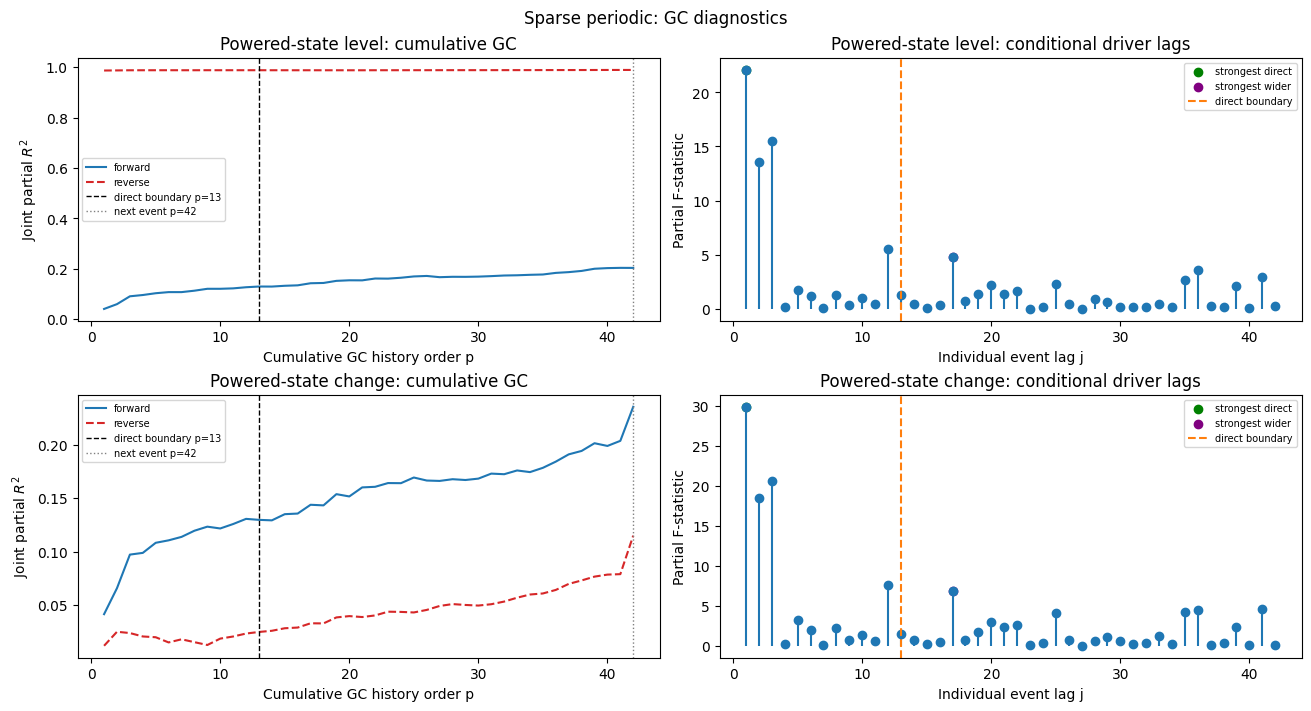

,target,direction,AIC order,BIC order,joint F,joint p,partial R^2
0,level,forward,3,1,20.7709,0.0000,0.0408
1,level,reverse,3,1,35794.5477,0.0000,0.9866
2,change,forward,3,1,20.9616,0.0000,0.0413
3,change,reverse,3,1,5.7344,0.0170,0.0116


,target,strongest j,coefficient,partial F,raw p,Holm p,Holm survives
0,level,1,0.0015,22.0682,0.0000,0.0002,True
1,change,1,0.0017,29.8886,0.0000,0.0000,True


,target,median_AIC_order,median_BIC_order,rejection_rate,median_partial_R2,modal_strongest_j
0,change,1.0000,1.0000,0.9800,0.0221,1
1,level,1.0000,1.0000,0.9800,0.0207,1


target,change,level
bic_order,,
1,47,47
2,3,3


target,change,level
strongest_lag,,
1,27,27
2,8,9
3,4,4
4,3,3
5,5,4
6,1,1
8,2,2


In [8]:
show_gc('sparse_periodic')

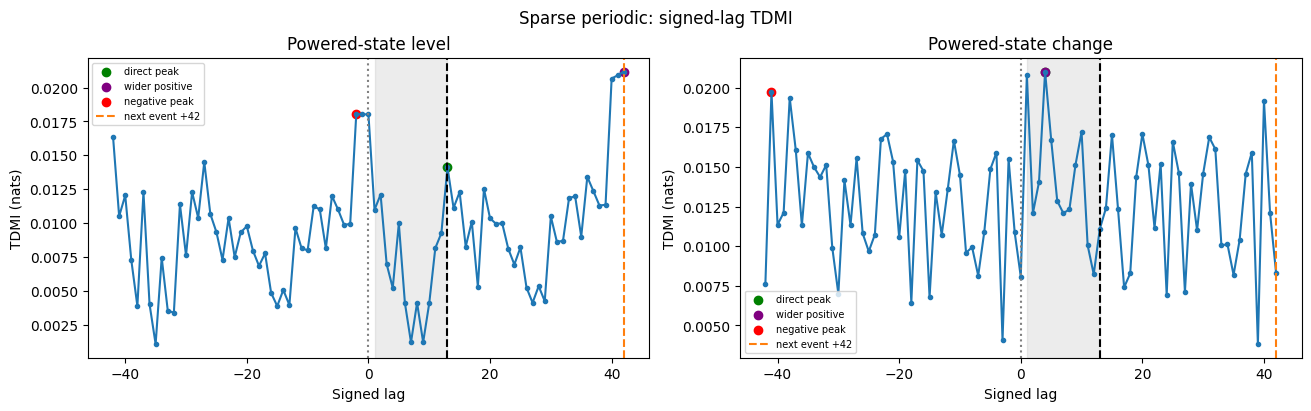

,target,representative direct lag,TDMI,best positive lag,best negative lag,global positive outside direct,scan-boundary rate
0,level,13,0.0141,42,-2,0.7000,0.0600
1,change,4,0.0210,4,-41,0.2000,0.0000


target,change,level
direct_peak_lag,,
1,17,5
2,9,3
3,5,1
4,4,1
5,3,1
6,2,2
7,2,5
8,4,2
9,2,10


In [9]:
show_tdmi('sparse_periodic')

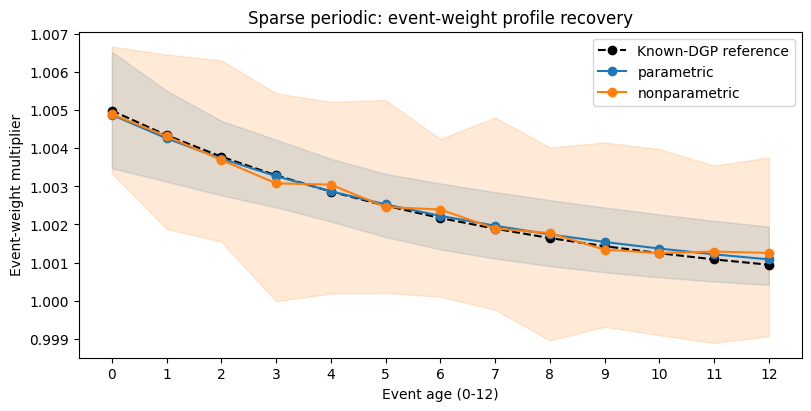

,true amplitude,mean estimated amplitude,absolute amplitude error,true decay rate,mean estimated decay rate,absolute decay error,parametric profile RMSE,non-parametric profile RMSE
0,0.01000,0.00978,0.00151,35.00000,33.34157,9.11619,0.00055,0.00145


In [10]:
show_profile('sparse_periodic')

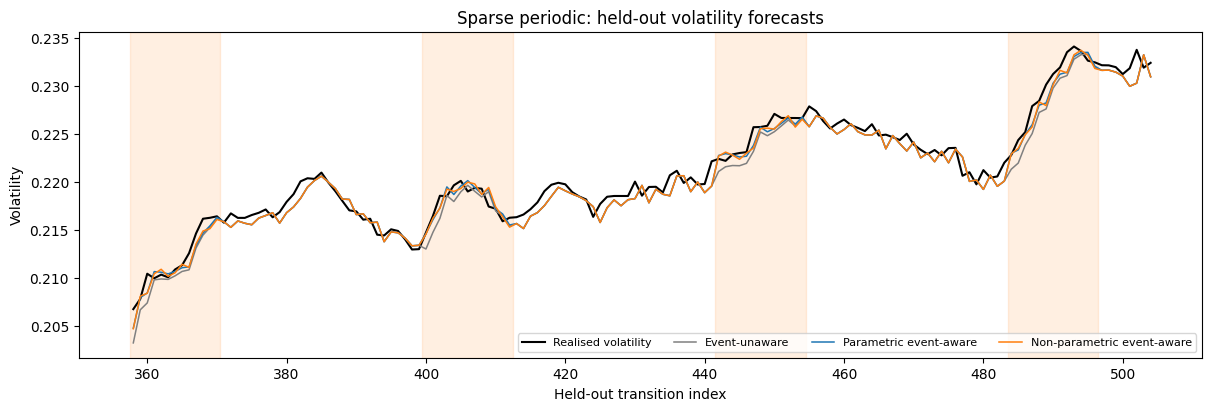

,unaware MAE,parametric MAE,non-parametric MAE,unaware RMSE,parametric RMSE,non-parametric RMSE,parametric MAE gain (%),non-parametric MAE gain (%),parametric 95% coverage,coverage error,interval score
0,0.0009,0.0007,0.0007,0.0011,0.0009,0.0009,19.0049,15.7227,0.9500,0.0286,0.0042


In [11]:
show_forecast('sparse_periodic')

Sparse-periodic finding: fewer observed events reduce profile-recovery stability and change GC effect size. Deterministic spacing can still generate wider-lag TDMI aliases; neither selected order p nor strongest lag j is proof of structural timing.

## 4. Sparse irregular analysis

Sparse irregular also has 12 events and retains a nominal period of 42 transitions, but realised spacing ranges from 21 to 69 transitions (median 34). There is no single irregular next-event boundary: wider-lag peaks are reported descriptively.

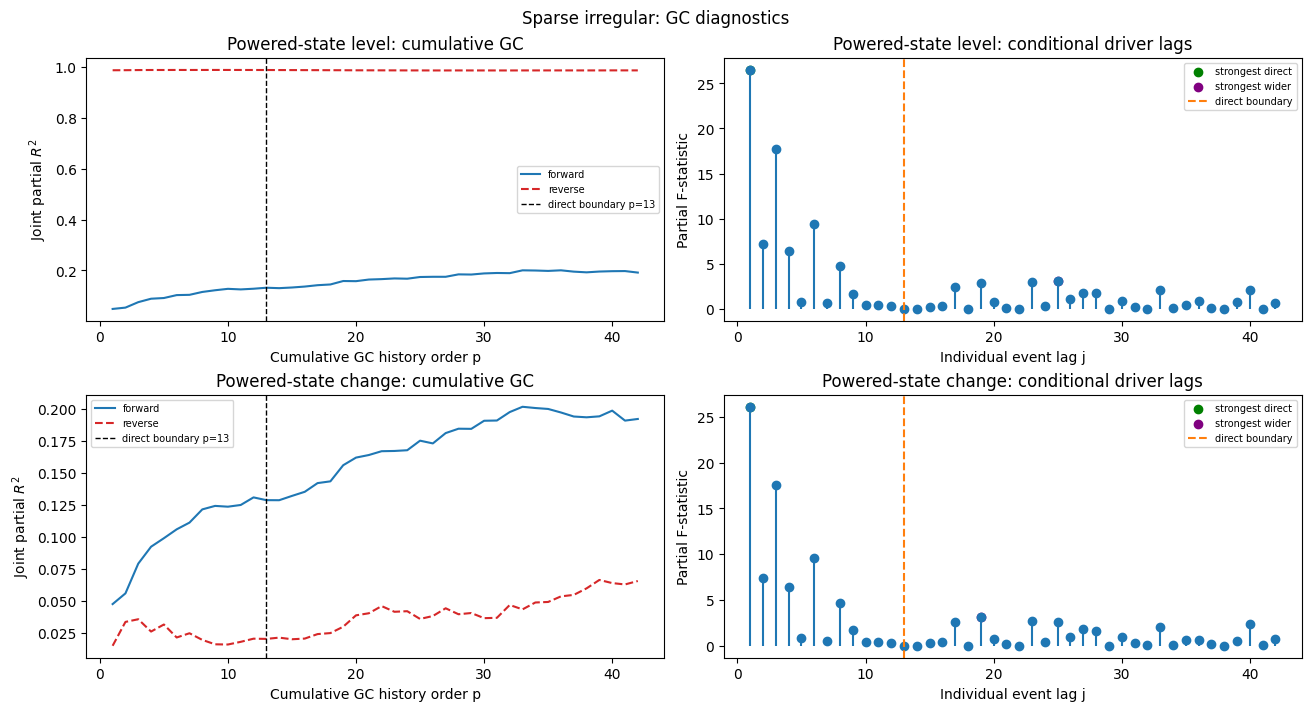

,target,direction,AIC order,BIC order,joint F,joint p,partial R^2
0,level,forward,3,1,24.9950,0.0000,0.0487
1,level,reverse,3,1,40173.3979,0.0000,0.9880
2,change,forward,3,1,24.3391,0.0000,0.0476
3,change,reverse,3,1,7.4484,0.0066,0.0151


,target,strongest j,coefficient,partial F,raw p,Holm p,Holm survives
0,level,1,0.0017,26.4863,0.0000,0.0000,True
1,change,1,0.0017,26.1136,0.0000,0.0000,True


,target,median_AIC_order,median_BIC_order,rejection_rate,median_partial_R2,modal_strongest_j
0,change,1.0000,1.0000,0.8600,0.0262,1
1,level,1.0000,1.0000,0.8600,0.0226,1


target,change,level
bic_order,,
1,46,45
2,4,5


target,change,level
strongest_lag,,
1,20,21
2,15,15
3,7,7
4,4,4
5,2,2
7,1,0
13,1,1


In [12]:
show_gc('sparse_irregular')

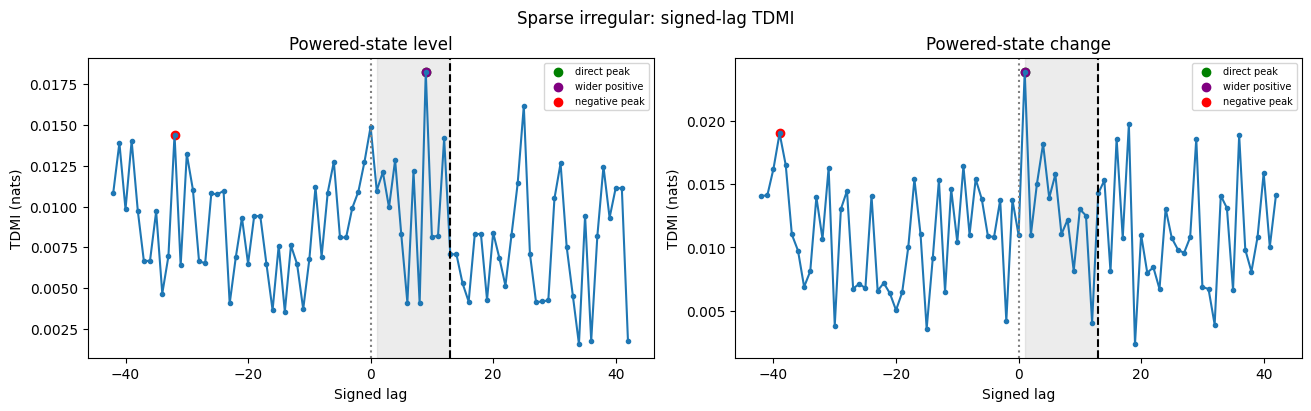

,target,representative direct lag,TDMI,best positive lag,best negative lag,global positive outside direct,scan-boundary rate
0,level,9,0.0183,9,-32,0.6600,0.0200
1,change,1,0.0239,1,-39,0.3000,0.0000


target,change,level
direct_peak_lag,,
1,21,5
2,11,6
3,3,3
4,4,2
5,2,2
6,2,2
7,0,3
8,1,1
9,0,5


In [13]:
show_tdmi('sparse_irregular')

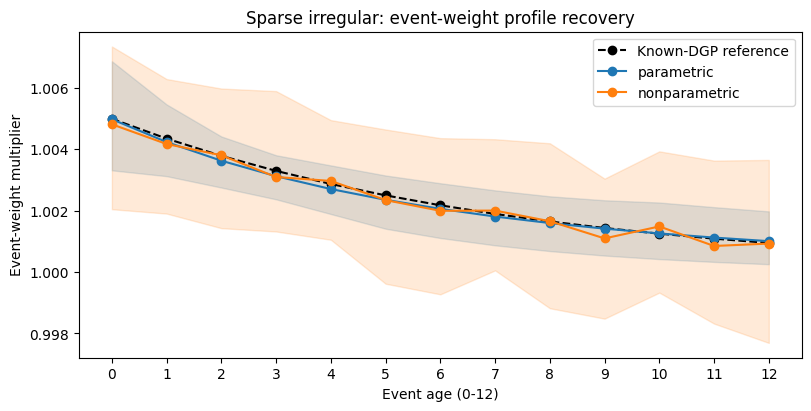

,true amplitude,mean estimated amplitude,absolute amplitude error,true decay rate,mean estimated decay rate,absolute decay error,parametric profile RMSE,non-parametric profile RMSE
0,0.01000,0.00997,0.00178,35.00000,37.98173,15.69348,0.00058,0.00149


In [14]:
show_profile('sparse_irregular')

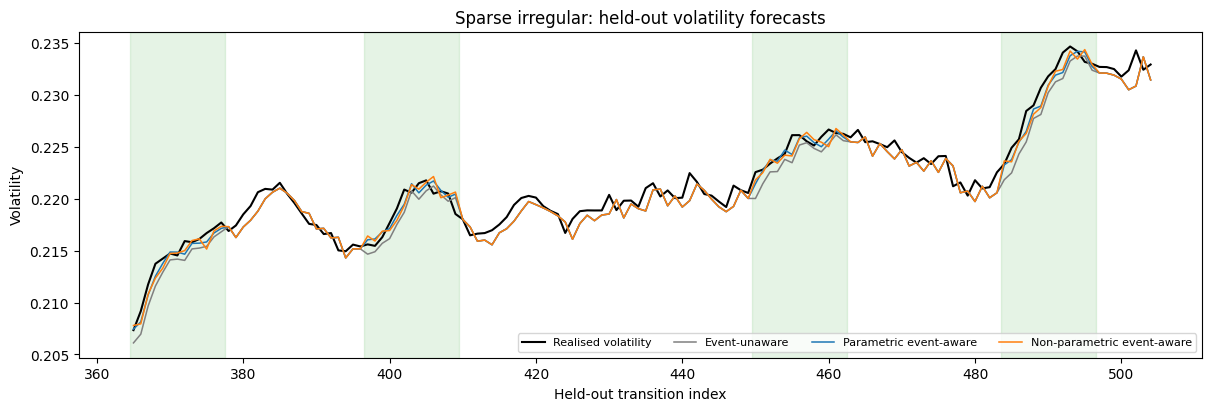

,unaware MAE,parametric MAE,non-parametric MAE,unaware RMSE,parametric RMSE,non-parametric RMSE,parametric MAE gain (%),non-parametric MAE gain (%),parametric 95% coverage,coverage error,interval score
0,0.0009,0.0007,0.0008,0.0011,0.0009,0.0009,18.9434,13.4209,0.9392,0.0269,0.0043


In [15]:
show_forecast('sparse_irregular')

Sparse-irregular finding: breaking exact periodicity lowers the strongest reverse predictive artefact, while the limited event count still constrains recovery. Event-aware forecasts remain useful; TDMI remains unsigned nonlinear lagged dependence rather than directional causality.

## 5. Final comparison across schedules

Only after the three case studies, the table and two figures summarise the paired repeated evidence. Sparse periodic minus dense periodic changes frequency, spacing and event count; sparse irregular minus sparse periodic is the schedule-regularity comparison.

,schedule,forward GC rejection,median selected GC p,modal strongest j,median GC partial R^2,TDMI direct-window peak rate,TDMI alias-peak rate,parametric profile RMSE,non-parametric profile RMSE,parametric active MAE gain,non-parametric active MAE gain,coverage error,interval score
0,Dense periodic,1.0000,1.0000,1,0.1307,1.0000,1.0000,0.0003,0.0010,25.1875,22.1318,0.0259,0.0042
1,Sparse periodic,0.9800,1.0000,1,0.1030,1.0000,1.0000,0.0005,0.0014,19.0049,15.7227,0.0286,0.0042
2,Sparse irregular,1.0000,1.0000,1,0.1003,1.0000,1.0000,0.0006,0.0015,18.9434,13.4209,0.0269,0.0043


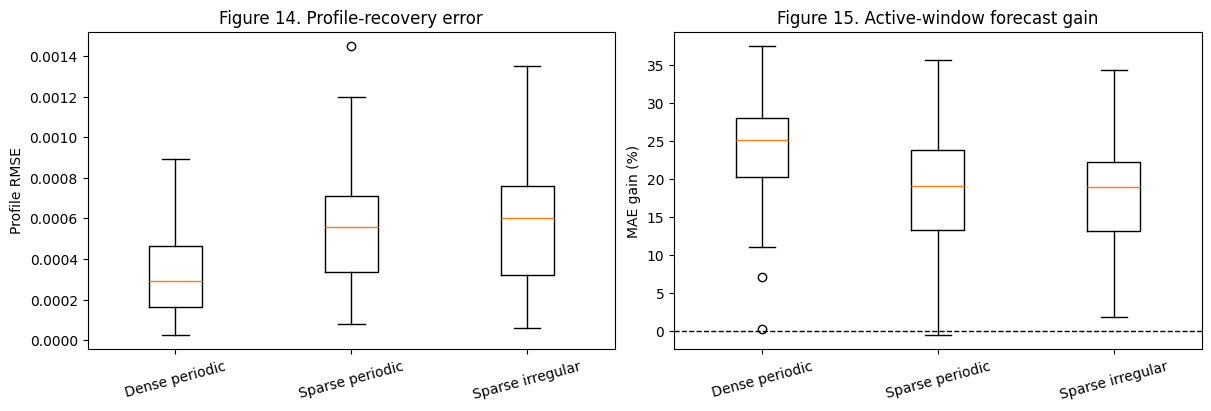

In [16]:
def rate(m,k): return float(rates.query('metric==@m and case_name==@k').iloc[0]['rate'])
def med(m,k): return float(numeric.query('metric==@m and case_name==@k').iloc[0]['median'])
final=pd.DataFrame([{'schedule':LABEL[k],'forward GC rejection':rate('gc_change_detected_5pct',k),'median selected GC p':gc_repeated.query('case==@k and target=="change"').bic_order.median(),'modal strongest j':gc_repeated.query('case==@k and target=="change"').strongest_lag.mode().iat[0],'median GC partial R^2':med('gc_change_partial_r_squared',k),'TDMI direct-window peak rate':(tdmi_metrics.query('case_name==@k and target=="change"').direct_peak_lag.between(1,13)).mean(),'TDMI alias-peak rate':(tdmi_metrics.query('case_name==@k and target=="change"').outside_direct_positive_peak_lag.abs()>13).mean(),'parametric profile RMSE':case_results.query('case_name==@k').parametric_profile_RMSE.mean(),'non-parametric profile RMSE':case_results.query('case_name==@k').nonparametric_profile_RMSE.mean(),'parametric active MAE gain':case_results.query('case_name==@k').active_sigma_parametric_MAE_gain_pct.median(),'non-parametric active MAE gain':case_results.query('case_name==@k').active_sigma_nonparametric_MAE_gain_pct.median(),'coverage error':case_results.query('case_name==@k').parametric_absolute_coverage_error.mean(),'interval score':case_results.query('case_name==@k').active_95_state_parametric_interval_score.mean()} for k in LABEL]); display(final.style.format(precision=4))
fig,axes=plt.subplots(1,2,figsize=(12,4),constrained_layout=True)
for ax,metric,title,ylabel in zip(axes,['parametric_profile_RMSE','active_sigma_parametric_MAE_gain_pct'],['Figure 14. Profile-recovery error','Figure 15. Active-window forecast gain'],['Profile RMSE','MAE gain (%)']):
    ax.boxplot([case_results.query('case_name==@k')[metric] for k in LABEL],tick_labels=[LABEL[k] for k in LABEL]); ax.axhline(0,color='black',ls='--',lw=1) if 'gain' in metric else None; ax.set(title=title,ylabel=ylabel); ax.tick_params(axis='x',rotation=15)
plt.show()

## 6. Concise findings and limitations

Event scarcity, rather than schedule irregularity alone, drives the clearest deterioration in profile recovery and forward-GC effect size. Exact periodicity accompanies stronger reverse predictive structure and aliases, but GC and TDMI remain predictive/dependence diagnostics, not structural proof. The event-response shape and scalar parameters are fixed, calendars are synthetic, and forecasting improvement does not guarantee accurate event-profile recovery.

In [17]:
assert all(no_overlap(v) for v in STEPS_BY_CASE.values()) and gc_repeated.groupby(['case','target']).size().eq(N_SEEDS).all()
assert len(gc_repeated)==300 and not gc_repeated[['selected_F','selected_partial_r2','strongest_F']].isna().any().any() and (gc_repeated.strongest_F>=0).all()
print('Notebook 10 executed: three schedule-specific GC, TDMI, profile-recovery and forecasting analyses; 50 paired seeds; final comparison last.')

Notebook 10 executed: three schedule-specific GC, TDMI, profile-recovery and forecasting analyses; 50 paired seeds; final comparison last.
